# PACSSUN 2603 Time-Domain Plots


In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import pytz

## ISAC1

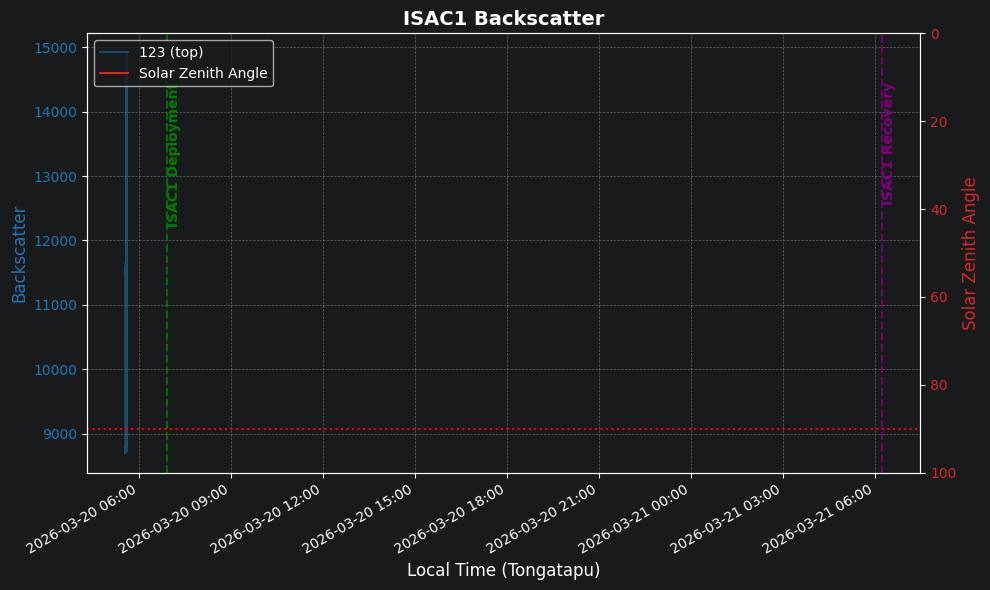

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

title = 'ISAC1 Backscatter'
df = pd.read_csv('ISAC1.csv')

# --- TIME CONVERSION LOGIC ---
# 1. Convert Unix seconds to UTC datetime
# 2. Convert from UTC to Tongatapu local time
df['dt_local'] = (
    pd.to_datetime(df['unixTime'], unit='s', utc=True)
    .dt.tz_convert('Pacific/Tongatapu')
)

# Optional: Sort by time to ensure lines don't "zig-zag" back and forth
df = df.sort_values('dt_local')

# Use the object-oriented interface (fig, ax)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the data series on the primary (left) y-axis
# Note: I'm using the new 'dt_local' column here
ax1.plot(df['dt_local'], df['backscatter_filtered_123'], label='123 (top) - shadow', color='tab:blue', alpha=0.1)
line1, = ax1.plot(df['dt_local'], df['backscatter_filtered_123'], label='123 (top)', color='tab:blue', alpha=0.5)

# Create a secondary y-axis for the solar zenith angle
ax2 = ax1.twinx()
line4, = ax2.plot(df['dt_local'], df['zenith'], label='Solar Zenith Angle', color='tab:red')

# Set Axis Labels
ax1.set_xlabel('Local Time (Tongatapu)', fontsize=12)
ax1.set_ylabel('Backscatter', fontsize=12, color='tab:blue')
ax2.set_ylabel('Solar Zenith Angle', fontsize=12, color='tab:red')

# Match the tick colors
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, 100)
ax2.invert_yaxis()
ax2.axhline(90, color='red', linestyle=':', label='Horizon (90°)')

# Vertical lines (Events) - These already use the correct timezone!
events = [
    (pd.Timestamp('2026-03-20 06:55', tz='Pacific/Tongatapu'), 'ISAC1 Deployment', 'green'),
    (pd.Timestamp('2026-03-21 06:14', tz='Pacific/Tongatapu'), 'ISAC1 Recovery', 'purple'),
]

for date, label, col in events:
    ax1.axvline(x=date, color=col, linestyle='--', linewidth=1.5, alpha=0.8)

    # Labeling near the top
    y_top = ax1.get_ylim()[1]
    ax1.text(date, y_top * 0.95, f' {label}',
             color=col, fontweight='bold', verticalalignment='top', rotation=90)

# Formatting the X-axis (Dates)
fig.autofmt_xdate()
# Matplotlib is smart enough to handle timezone-aware pandas objects
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M', tz='Pacific/Tongatapu'))

# Combine legends
lines = [line1, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title(title, fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(title + ".png")
plt.show()

In [70]:
# title = 'ISAC1 Backscatter'
# df = pd.read_csv('ISAC1.csv')
# df['Datetime']=pd.to_datetime(df['Datetime'])
#
# # df = df.sort_values('Datetime')
# # Use the object-oriented interface (fig, ax) for easier control of twin axes
# fig, ax1 = plt.subplots(figsize=(10, 6))
#
# # Plot the data series on the primary (left) y-axis
# line1, = ax1.plot(df['Datetime'], df['backscatter_filtered_123'], label='123 (top)', color='tab:blue', alpha = 0.1)
# line1, = ax1.plot(df['Datetime'], df['backscatter_filtered_123'], label='123 (top)', color='tab:blue', alpha = 0.5)
#
# # line3, = ax1.plot(df['Datetime'], df['backscatter_113'], label='113 (mid-low)', color='tab:green')
#
# # Create a secondary y-axis for the solar zenith angle
# ax2 = ax1.twinx()
# line4, = ax2.plot(df['Datetime'], df['zenith'], label='Solar Zenith Angle', color='tab:red')
#
# # Set Axis Labels
# ax1.set_xlabel('Datetime', fontsize=12)
# ax1.set_ylabel('Backscatter', fontsize=12, color='tab:blue')
# ax2.set_ylabel('Solar Zenith Angle', fontsize=12, color='tab:red')
#
# # Match the tick colors to the line colors for clarity
# ax1.tick_params(axis='y', labelcolor='tab:blue')
# ax2.tick_params(axis='y', labelcolor='tab:red')
# ax2.set_ylim(0, 100)
# ax2.invert_yaxis()  # Zenith is 0° at the top (overhead)
# ax2.axhline(90, color='red', linestyle=':', label='Horizon (90°)')
#
# # 1. Define your vertical lines (Date, Label, and Color)
# events = [
#     (pd.Timestamp('2026-03-20 06:55', tz='Pacific/Tongatapu'), 'ISAC1 Deployment', 'green'),
#     (pd.Timestamp('2026-03-21 06:14', tz='Pacific/Tongatapu'), 'ISAC1 Recovery', 'purple'),
# ]
#
# # 2. Add the lines to the plot
# for date, label, col in events:
#     # axvline draws the line; transform=ax1.get_xaxis_transform() ensures it spans the plot
#     ax1.axvline(x=date, color=col, linestyle='--', linewidth=1.5, alpha=0.8)
#
#     # Add a text label near the top of the plot
#     # x=date, y=0.95 (95% up the axis)
#     ax1.text(date, ax1.get_ylim()[1] * 0.95, f' {label}',
#              color=col, fontweight='bold', verticalalignment='top', rotation=90)
#
# # Combine legends from both axes into one box
# # Note: If you want the vertical lines in the legend, you'd add them here
# lines = [line1, line4]
# labels = [l.get_label() for l in lines]
# ax1.legend(lines, labels, loc='upper left')
#
#
# # Formatting the X-axis (Dates)
# fig.autofmt_xdate()
# ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
#
# # Combine legends from both axes into one box
# lines = [line1, line4]
# labels = [l.get_label() for l in lines]
# ax1.legend(lines, labels, loc='upper left')
#
# plt.title(title, fontsize=14, fontweight='bold')
# ax1.grid(True, linestyle='--', alpha=0.5)
# plt.tight_layout()
#
# plt.savefig(title+".png")
# plt.show()


In [71]:
df

,unixTime,background_123,ambient_123,backscatter_123,pressure_123,waterTemp_123,battery_123,backscatter_filtered_123,ambient_filtered_123,Datetime,...,AgeInSeconds,BatteryVoltage,GpsQuality,Latitude,Longitude,SubmergedBoolean,Temperature0cm,Unnamed: 11,station,dt_local
0,1773937975,122,181,8709,0,2000,133,NaN,NaN,2026-03-20 05:32:55+13:00,...,59409,12.0,3,-21.012431,-175.835849,0,NaN,NaN,346,2026-03-20 05:32:55+13:00
20,1773937975,1013,228,8715,0,2000,133,8711.5,237.0,2026-03-20 05:32:55+13:00,...,59409,12.0,3,-21.012431,-175.835849,0,NaN,NaN,346,2026-03-20 05:32:55+13:00
19,1773937975,968,238,8708,0,2000,133,8711.5,236.0,2026-03-20 05:32:55+13:00,...,59409,12.0,3,-21.012431,-175.835849,0,NaN,NaN,346,2026-03-20 05:32:55+13:00
18,1773937975,925,236,8715,0,2000,133,8711.5,228.0,2026-03-20 05:32:55+13:00,...,59409,12.0,3,-21.012431,-175.835849,0,NaN,NaN,346,2026-03-20 05:32:55+13:00
17,1773937975,880,220,8714,0,2000,133,8711.5,225.0,2026-03-20 05:32:55+13:00,...,59409,12.0,3,-21.012431,-175.835849,0,NaN,NaN,346,2026-03-20 05:32:55+13:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3681,1773938141,163381,238,8835,0,2000,91,8835.5,243.0,2026-03-20 05:35:41+13:00,...,59409,12.0,3,-21.012431,-175.835849,0,NaN,NaN,346,2026-03-20 05:35:41+13:00
3680,1773938141,163336,243,8834,0,2000,91,8836.5,243.0,2026-03-20 05:35:41+13:00,...,59409,12.0,3,-21.012431,-175.835849,0,NaN,NaN,346,2026-03-20 05:35:41+13:00
3695,1773938141,164042,252,8831,0,2000,91,NaN,NaN,2026-03-20 05:35:41+13:00,...,59409,12.0,3,-21.012431,-175.835849,0,NaN,NaN,346,2026-03-20 05:35:41+13:00
3687,1773938141,163686,244,8831,0,2000,91,8834.0,244.0,2026-03-20 05:35:41+13:00,...,59409,12.0,3,-21.012431,-175.835849,0,NaN,NaN,346,2026-03-20 05:35:41+13:00


Ambient light:

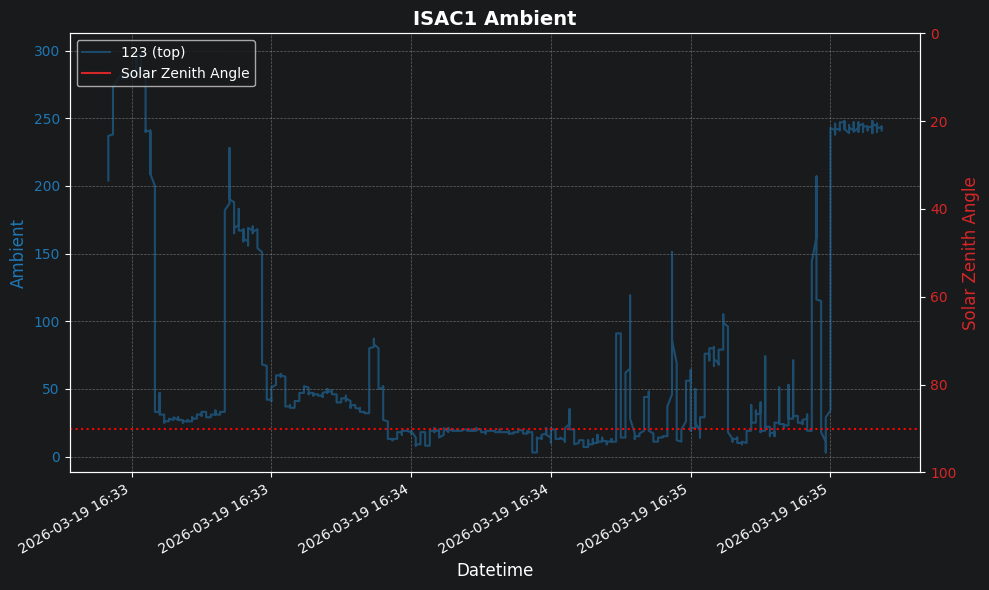

In [72]:
df = pd.read_csv('ISAC1.csv')

# df = df.sort_values('Datetime')
df['Datetime']=pd.to_datetime(df['Datetime'])
# Use the object-oriented interface (fig, ax) for easier control of twin axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the data series on the primary (left) y-axis
line1, = ax1.plot(df['Datetime'], df['ambient_filtered_123'], label='123 (top)', color='tab:blue', alpha = 0.1)
line1, = ax1.plot(df['Datetime'], df['ambient_filtered_123'], label='123 (top)', color='tab:blue', alpha = 0.5)

# line3, = ax1.plot(df['Datetime'], df['backscatter_113'], label='113 (mid-low)', color='tab:green')

# Create a secondary y-axis for the solar zenith angle
ax2 = ax1.twinx()
line4, = ax2.plot(df['Datetime'], df['zenith'], label='Solar Zenith Angle', color='tab:red')

# Set Axis Labels
ax1.set_xlabel('Datetime', fontsize=12)
ax1.set_ylabel('Ambient', fontsize=12, color='tab:blue')
ax2.set_ylabel('Solar Zenith Angle', fontsize=12, color='tab:red')

# Match the tick colors to the line colors for clarity
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, 100)
ax2.invert_yaxis()  # Zenith is 0° at the top (overhead)
ax2.axhline(90, color='red', linestyle=':', label='Horizon (90°)')


# Formatting the X-axis (Dates)
fig.autofmt_xdate()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))

# Combine legends from both axes into one box
lines = [line1, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')


title = 'ISAC1 Ambient'
plt.title(title, fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(title+".png")
plt.show()

## ISAC2

Backscatter:

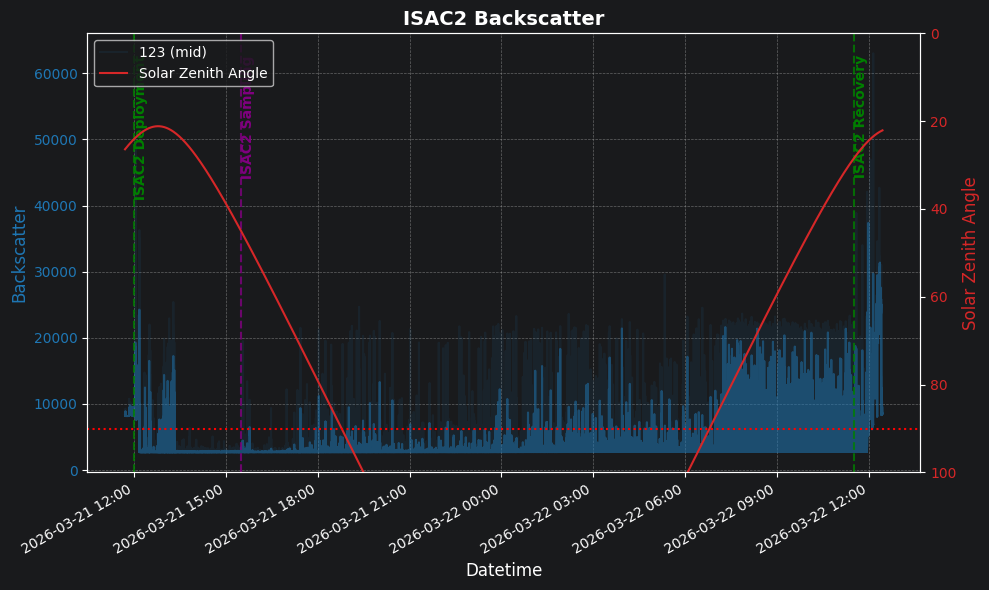

In [73]:
df = pd.read_csv('ISAC2.csv')

# df = df.sort_values('Datetime')
df['Datetime']=pd.to_datetime(df['Datetime']).dt.tz_convert('Pacific/Tongatapu')
# Use the object-oriented interface (fig, ax) for easier control of twin axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the first two series on the primary (left) y-axis
line1, = ax1.plot(df['Datetime'], df['backscatter_123'], label='123 (mid)', color='tab:blue', alpha = 0.1)
line2, = ax1.plot(df['Datetime'], df['backscatter_filtered_123'], label='123 (mid)', color='tab:blue', alpha = 0.5)


# Create a secondary y-axis for the solar zenith angle
ax2 = ax1.twinx()
line4, = ax2.plot(df['Datetime'], df['zenith'], label='Solar Zenith Angle', color='tab:red')

# Set Axis Labels
ax1.set_xlabel('Datetime', fontsize=12)
ax1.set_ylabel('Backscatter', fontsize=12, color='tab:blue')
ax2.set_ylabel('Solar Zenith Angle', fontsize=12, color='tab:red')

# Match the tick colors to the line colors for clarity
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, 100)
ax2.invert_yaxis()  # Zenith is 0° at the top (overhead)
ax2.axhline(90, color='red', linestyle=':', label='Horizon (90°)')

# 1. Define your vertical lines (Date, Label, and Color)
events = [
    (pd.Timestamp('2026-03-21 12:00', tz='Pacific/Tongatapu'), 'ISAC2 Deployment', 'green'),
    (pd.Timestamp('2026-03-21 15:30', tz='Pacific/Tongatapu'), 'ISAC2 Sampling', 'purple'),
    (pd.Timestamp('2026-03-22 11:31', tz='Pacific/Tongatapu'), 'ISAC2 Recovery', 'green'),
]

# 2. Add the lines to the plot
for date, label, col in events:
    # axvline draws the line; transform=ax1.get_xaxis_transform() ensures it spans the plot
    ax1.axvline(x=date, color=col, linestyle='--', linewidth=1.5, alpha=0.8)

    # Add a text label near the top of the plot
    # x=date, y=0.95 (95% up the axis)
    ax1.text(date, ax1.get_ylim()[1] * 0.95, f' {label}',
             color=col, fontweight='bold', verticalalignment='top', rotation=90)



# Formatting the X-axis (Dates)
tongatapu_tz = pytz.timezone('Pacific/Tongatapu')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M', tz=tongatapu_tz))

fig.autofmt_xdate()

# Combine legends from both axes into one box
lines = [line1, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

title = 'ISAC2 Backscatter'
plt.title(title, fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(title+".png")
plt.show()

Ambient:

In [75]:
import time
test_val = 1773912775  # Replace with one of yours
print(f"Standard UTC conversion: {time.strftime('%Y-%m-%d %H:%M:%S', time.gmtime(test_val))}")

Standard UTC conversion: 2026-03-19 09:32:55


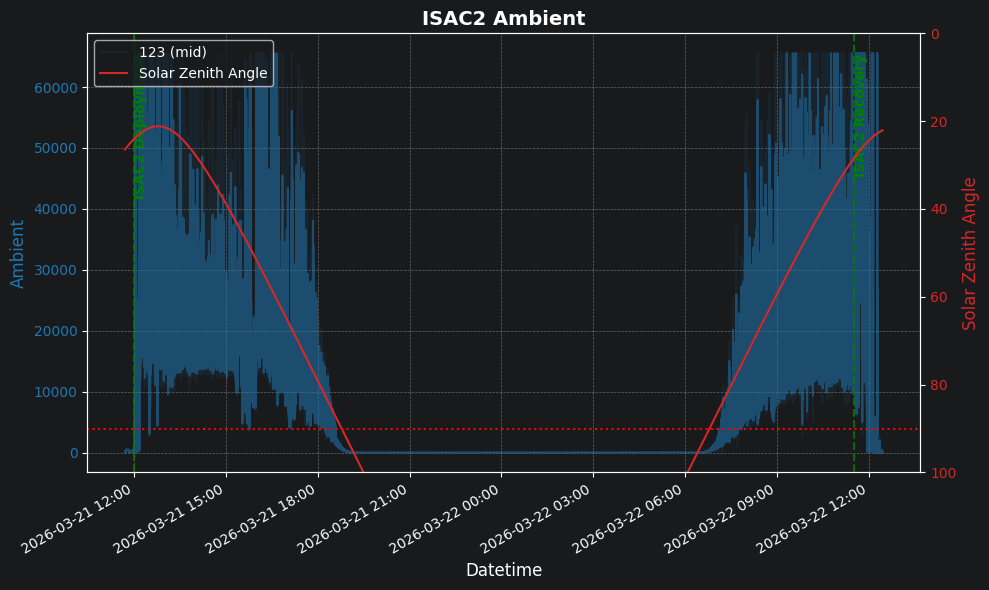

In [76]:
df = pd.read_csv('ISAC2.csv')

# df = df.sort_values('Datetime')
df['Datetime']=pd.to_datetime(df['Datetime']).dt.tz_convert('Pacific/Tongatapu')
# Use the object-oriented interface (fig, ax) for easier control of twin axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the first two series on the primary (left) y-axis
line1, = ax1.plot(df['Datetime'], df['ambient_123'], label='123 (mid)', color='tab:blue', alpha = 0.1)
line2, = ax1.plot(df['Datetime'], df['ambient_filtered_123'], label='123 (mid)', color='tab:blue', alpha = 0.5)


# Create a secondary y-axis for the solar zenith angle
ax2 = ax1.twinx()
line4, = ax2.plot(df['Datetime'], df['zenith'], label='Solar Zenith Angle', color='tab:red')

# Set Axis Labels
ax1.set_xlabel('Datetime', fontsize=12)
ax1.set_ylabel('Ambient', fontsize=12, color='tab:blue')
ax2.set_ylabel('Solar Zenith Angle', fontsize=12, color='tab:red')

# Match the tick colors to the line colors for clarity
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, 100)
ax2.invert_yaxis()  # Zenith is 0° at the top (overhead)
ax2.axhline(90, color='red', linestyle=':', label='Horizon (90°)')
# 1. Define your vertical lines (Date, Label, and Color)
events = [
    (pd.Timestamp('2026-03-21 12:00', tz='Pacific/Tongatapu'), 'ISAC2 Deployment', 'green'),
    (pd.Timestamp('2026-03-21 15:30', tz='Pacific/Tongatapu'), 'ISAC2 Sampling', 'purple'),
    (pd.Timestamp('2026-03-22 11:31', tz='Pacific/Tongatapu'), 'ISAC2 Recovery', 'green'),
]

# 2. Add the lines to the plot
for date, label, col in events:
    # axvline draws the line; transform=ax1.get_xaxis_transform() ensures it spans the plot
    ax1.axvline(x=date, color=col, linestyle='--', linewidth=1.5, alpha=0.8)

    # Add a text label near the top of the plot
    # x=date, y=0.95 (95% up the axis)
    ax1.text(date, ax1.get_ylim()[1] * 0.95, f' {label}',
             color=col, fontweight='bold', verticalalignment='top', rotation=90)



# Formatting the X-axis (Dates)
tongatapu_tz = pytz.timezone('Pacific/Tongatapu')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M', tz=tongatapu_tz))

fig.autofmt_xdate()

# Combine legends from both axes into one box
lines = [line1, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

title = 'ISAC2 Ambient'
plt.title(title, fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(title+".png")
plt.show()

## ISAC3

Backscatter:

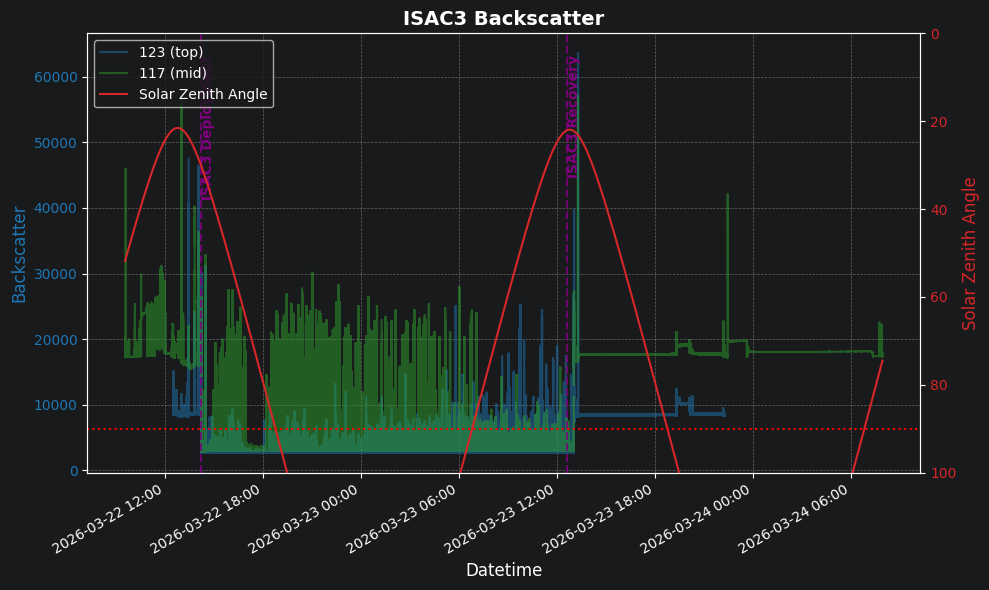

In [77]:
df = pd.read_csv('ISAC3.csv')

# df = df.sort_values('Datetime')
df['Datetime']=pd.to_datetime(df['Datetime']).dt.tz_convert('Pacific/Tongatapu')
# Use the object-oriented interface (fig, ax) for easier control of twin axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the first two series on the primary (left) y-axis
line1, = ax1.plot(df['Datetime'], df['backscatter_filtered_123'], label='123 (top)', color='tab:blue', alpha = 0.5)
line2, = ax1.plot(df['Datetime'], df['backscatter_filtered_117'], label='117 (mid)', color='tab:green', alpha = 0.5)
# line3, = ax1.plot(df['Datetime'], df['backscatter_113'], label='113 (mid-low)', color='tab:green')

# Create a secondary y-axis for the solar zenith angle
ax2 = ax1.twinx()
line4, = ax2.plot(df['Datetime'], df['zenith'], label='Solar Zenith Angle', color='tab:red')

# Set Axis Labels
ax1.set_xlabel('Datetime', fontsize=12)
ax1.set_ylabel('Backscatter', fontsize=12, color='tab:blue')
ax2.set_ylabel('Solar Zenith Angle', fontsize=12, color='tab:red')

# Match the tick colors to the line colors for clarity
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, 100)
ax2.invert_yaxis()  # Zenith is 0° at the top (overhead)
ax2.axhline(90, color='red', linestyle=':', label='Horizon (90°)')


# 1. Define your vertical lines (Date, Label, and Color)
events = [
    (pd.Timestamp('2026-03-22 14:13', tz='Pacific/Tongatapu'), 'ISAC3 Deployment', 'purple'),
    # (pd.Timestamp('2026-03-21 15:30', tz='Pacific/Tongatapu'), 'ISAC2 Sampling', 'purple'),
    (pd.Timestamp('2026-03-23 12:38', tz='Pacific/Tongatapu'), 'ISAC3 Recovery', 'purple'),
]

# 2. Add the lines to the plot
for date, label, col in events:
    # axvline draws the line; transform=ax1.get_xaxis_transform() ensures it spans the plot
    ax1.axvline(x=date, color=col, linestyle='--', linewidth=1.5, alpha=0.8)

    # Add a text label near the top of the plot
    # x=date, y=0.95 (95% up the axis)
    ax1.text(date, ax1.get_ylim()[1] * 0.95, f' {label}',
             color=col, fontweight='bold', verticalalignment='top', rotation=90)



# Formatting the X-axis (Dates)
tongatapu_tz = pytz.timezone('Pacific/Tongatapu')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M', tz=tongatapu_tz))

fig.autofmt_xdate()

# Combine legends from both axes into one box
lines = [line1, line2, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

title = 'ISAC3 Backscatter'
plt.title(title, fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(title+".png")
plt.show()

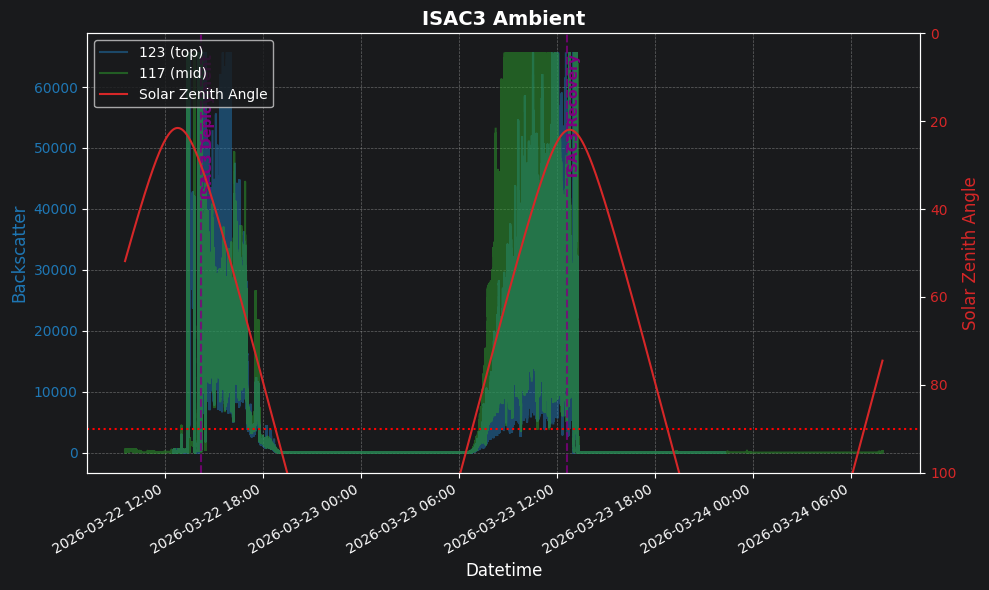

In [78]:
df = pd.read_csv('ISAC3.csv')

# df = df.sort_values('Datetime')
df['Datetime']=pd.to_datetime(df['Datetime'])#.dt.tz_localize'Pacific/Tongatapu')
# Use the object-oriented interface (fig, ax) for easier control of twin axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the first two series on the primary (left) y-axis
line1, = ax1.plot(df['Datetime'], df['ambient_filtered_123'], label='123 (top)', color='tab:blue', alpha = 0.5)
line2, = ax1.plot(df['Datetime'], df['ambient_filtered_117'], label='117 (mid)', color='tab:green', alpha = 0.5)
# line3, = ax1.plot(df['Datetime'], df['backscatter_113'], label='113 (mid-low)', color='tab:green')

# Create a secondary y-axis for the solar zenith angle
ax2 = ax1.twinx()
line4, = ax2.plot(df['Datetime'], df['zenith'], label='Solar Zenith Angle', color='tab:red')

# Set Axis Labels
ax1.set_xlabel('Datetime', fontsize=12)
ax1.set_ylabel('Backscatter', fontsize=12, color='tab:blue')
ax2.set_ylabel('Solar Zenith Angle', fontsize=12, color='tab:red')

# Match the tick colors to the line colors for clarity
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, 100)
ax2.invert_yaxis()  # Zenith is 0° at the top (overhead)
ax2.axhline(90, color='red', linestyle=':', label='Horizon (90°)')


# 1. Define your vertical lines (Date, Label, and Color)
events = [
    (pd.Timestamp('2026-03-22 14:13', tz='Pacific/Tongatapu'), 'ISAC3 Deployment', 'purple'),
    # (pd.Timestamp('2026-03-21 15:30', tz='Pacific/Tongatapu'), 'ISAC2 Sampling', 'purple'),
    (pd.Timestamp('2026-03-23 12:38', tz='Pacific/Tongatapu'), 'ISAC3 Recovery', 'purple'),
]

# 2. Add the lines to the plot
for date, label, col in events:
    # axvline draws the line; transform=ax1.get_xaxis_transform() ensures it spans the plot
    ax1.axvline(x=date, color=col, linestyle='--', linewidth=1.5, alpha=0.8)

    # Add a text label near the top of the plot
    # x=date, y=0.95 (95% up the axis)
    ax1.text(date, ax1.get_ylim()[1] * 0.95, f' {label}',
             color=col, fontweight='bold', verticalalignment='top', rotation=90)



# Formatting the X-axis (Dates)
tongatapu_tz = pytz.timezone('Pacific/Tongatapu')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M', tz=tongatapu_tz))

fig.autofmt_xdate()

# Combine legends from both axes into one box
lines = [line1, line2, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

title = 'ISAC3 Ambient'
plt.title(title, fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(title+".png")
plt.show()

Ambient: